In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
files.upload()

['MPG', 'Cyl', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Year', 'CountryCode', 'Model']
['18', '8', '307', '130', '3504', '12', '70', '1', 'chevrolet chevelle malibu']
['15', '8', '350', '165', '3693', '11.5', '70', '1', 'buick skylark 320']
['18', '8', '318', '150', '3436', '11', '70', '1', 'plymouth satellite']
['16', '8', '304', '150', '3433', '12', '70', '1', 'amc rebel sst']
['17', '8', '302', '140', '3449', '10.5', '70', '1', 'ford torino']
['15', '8', '429', '198', '4341', '10', '70', '1', 'ford galaxie 500']
['14', '8', '454', '220', '4354', '9', '70', '1', 'chevrolet impala']
['14', '8', '440', '215', '4312', '8.5', '70', '1', 'plymouth fury iii']
['14', '8', '455', '225', '4425', '10', '70', '1', 'pontiac catalina']
['15', '8', '390', '190', '3850', '8.5', '70', '1', 'amc ambassador dpl']
['15', '8', '383', '170', '3563', '10', '70', '1', 'dodge challenger se']
['14', '8', '340', '160', '3609', '8', '70', '1', "plymouth 'cuda 340"]
['15', '8', '400', '150', '37

In [3]:
import pandas as pd
df=pd.read_csv('MPG data for various automobiles.csv')
print(df.head())

    MPG  Cyl  Displacement  Horsepower  Weight  Acceleration  Year  \
0  18.0    8         307.0         130    3504          12.0    70   
1  15.0    8         350.0         165    3693          11.5    70   
2  18.0    8         318.0         150    3436          11.0    70   
3  16.0    8         304.0         150    3433          12.0    70   
4  17.0    8         302.0         140    3449          10.5    70   

   CountryCode                      Model  
0            1  chevrolet chevelle malibu  
1            1          buick skylark 320  
2            1         plymouth satellite  
3            1              amc rebel sst  
4            1                ford torino  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cyl           392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    int64  
 4   Weight        392 non-null    int64  
 5   Acceleration  392 non-null    float64
 6   Year          392 non-null    int64  
 7   CountryCode   392 non-null    int64  
 8   Model         392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


In [5]:
df.head()

,MPG,Cyl,Displacement,Horsepower,Weight,Acceleration,Year,CountryCode,Model
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.shape

(392, 9)

In [7]:
df.describe()

,MPG,Cyl,Displacement,Horsepower,Weight,Acceleration,Year,CountryCode
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [8]:
Columnas_eliminar =['Year','CountryCode','Model']

In [9]:
df=df.drop(Columnas_eliminar, axis=1)
print(df)

      MPG  Cyl  Displacement  Horsepower  Weight  Acceleration
0    18.0    8         307.0         130    3504          12.0
1    15.0    8         350.0         165    3693          11.5
2    18.0    8         318.0         150    3436          11.0
3    16.0    8         304.0         150    3433          12.0
4    17.0    8         302.0         140    3449          10.5
..    ...  ...           ...         ...     ...           ...
387  27.0    4         140.0          86    2790          15.6
388  44.0    4          97.0          52    2130          24.6
389  32.0    4         135.0          84    2295          11.6
390  28.0    4         120.0          79    2625          18.6
391  31.0    4         119.0          82    2720          19.4

[392 rows x 6 columns]


In [10]:
print(df.corr())

                   MPG       Cyl  Displacement  Horsepower    Weight  \
MPG           1.000000 -0.777618     -0.805127   -0.778427 -0.832244   
Cyl          -0.777618  1.000000      0.950823    0.842983  0.897527   
Displacement -0.805127  0.950823      1.000000    0.897257  0.932994   
Horsepower   -0.778427  0.842983      0.897257    1.000000  0.864538   
Weight       -0.832244  0.897527      0.932994    0.864538  1.000000   
Acceleration  0.423329 -0.504683     -0.543800   -0.689196 -0.416839   

              Acceleration  
MPG               0.423329  
Cyl              -0.504683  
Displacement     -0.543800  
Horsepower       -0.689196  
Weight           -0.416839  
Acceleration      1.000000  


In [11]:
label_encoder = LabelEncoder()
df['Cyl'] = label_encoder.fit_transform(df['Cyl'])

In [12]:
X = df[['Cyl','Displacement', 'Horsepower', 'Weight', 'Acceleration' ]]
y = df['MPG'] 
print(X.shape)
print(y.shape)

(392, 5)
(392,)


In [13]:
#Vamos a subdividir nuestros datos en entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((274, 5), (118, 5), (274,), (118,))

In [14]:
#definimos el modelo
modelo = LinearRegression()

#Entrenamos el modelo
modelo.fit(X_train,y_train)

LinearRegression()

In [15]:
#Ahora podemos hacer las predicciones con el modelo entrenado
y_pred = modelo.predict(X_test)


In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error:{mse}')
print(f'R-squared(R2):{r2}')   

Mean Squared Error:19.64655680277396
R-squared(R2):0.6806245787097216


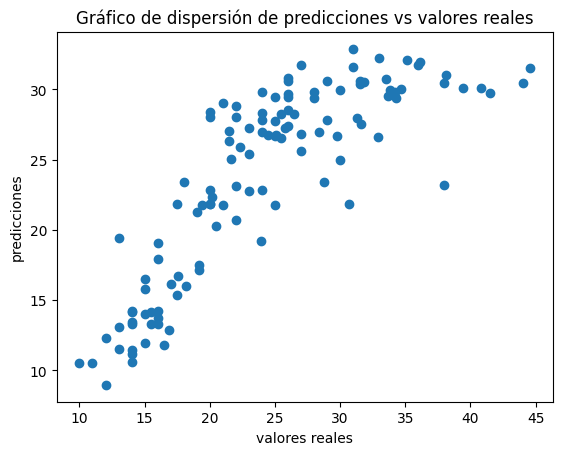

In [17]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('valores reales')
plt.ylabel('predicciones')
plt.title('Gráfico de dispersión de predicciones vs valores reales')
plt.show()

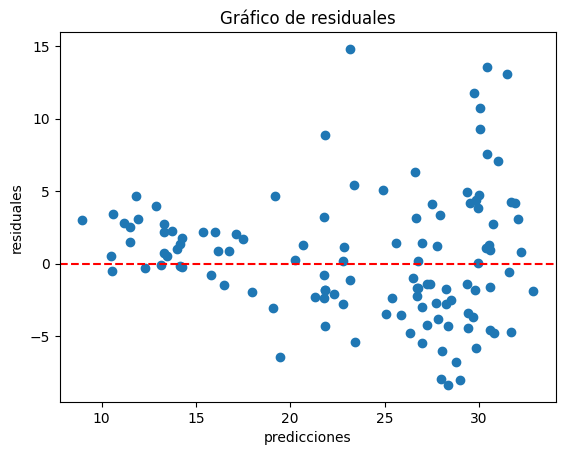

In [18]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('predicciones')
plt.ylabel('residuales')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de residuales')
plt.show()

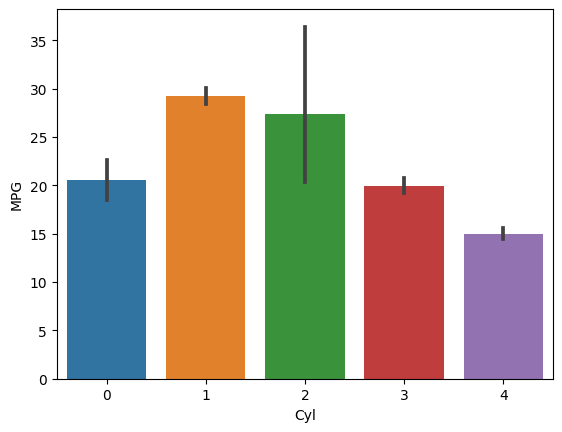

In [19]:
import seaborn as sns
sns.barplot(data=df, x='Cyl', y='MPG')
plt.show()

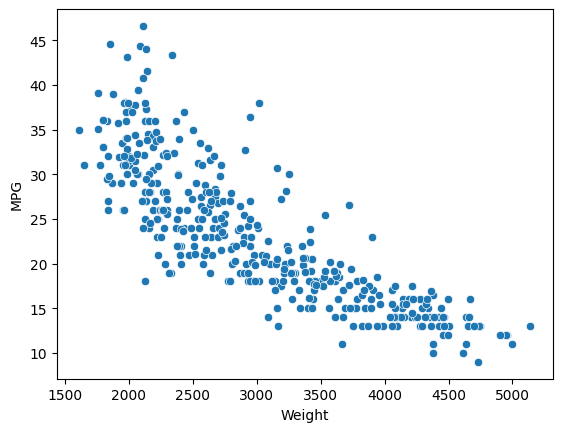

In [20]:
import seaborn as sns
sns.scatterplot(data=df, x='Weight', y='MPG')
plt.show()

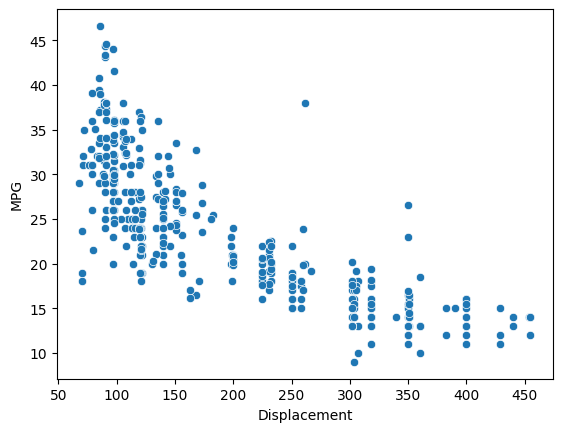

In [21]:
import seaborn as sns
sns.scatterplot(data=df, x='Displacement', y='MPG')
plt.show()

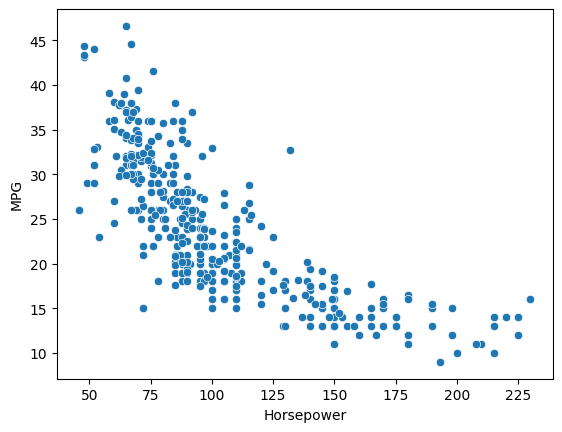

In [22]:
import seaborn as sns
sns.scatterplot(data=df, x='Horsepower', y='MPG')
plt.show()

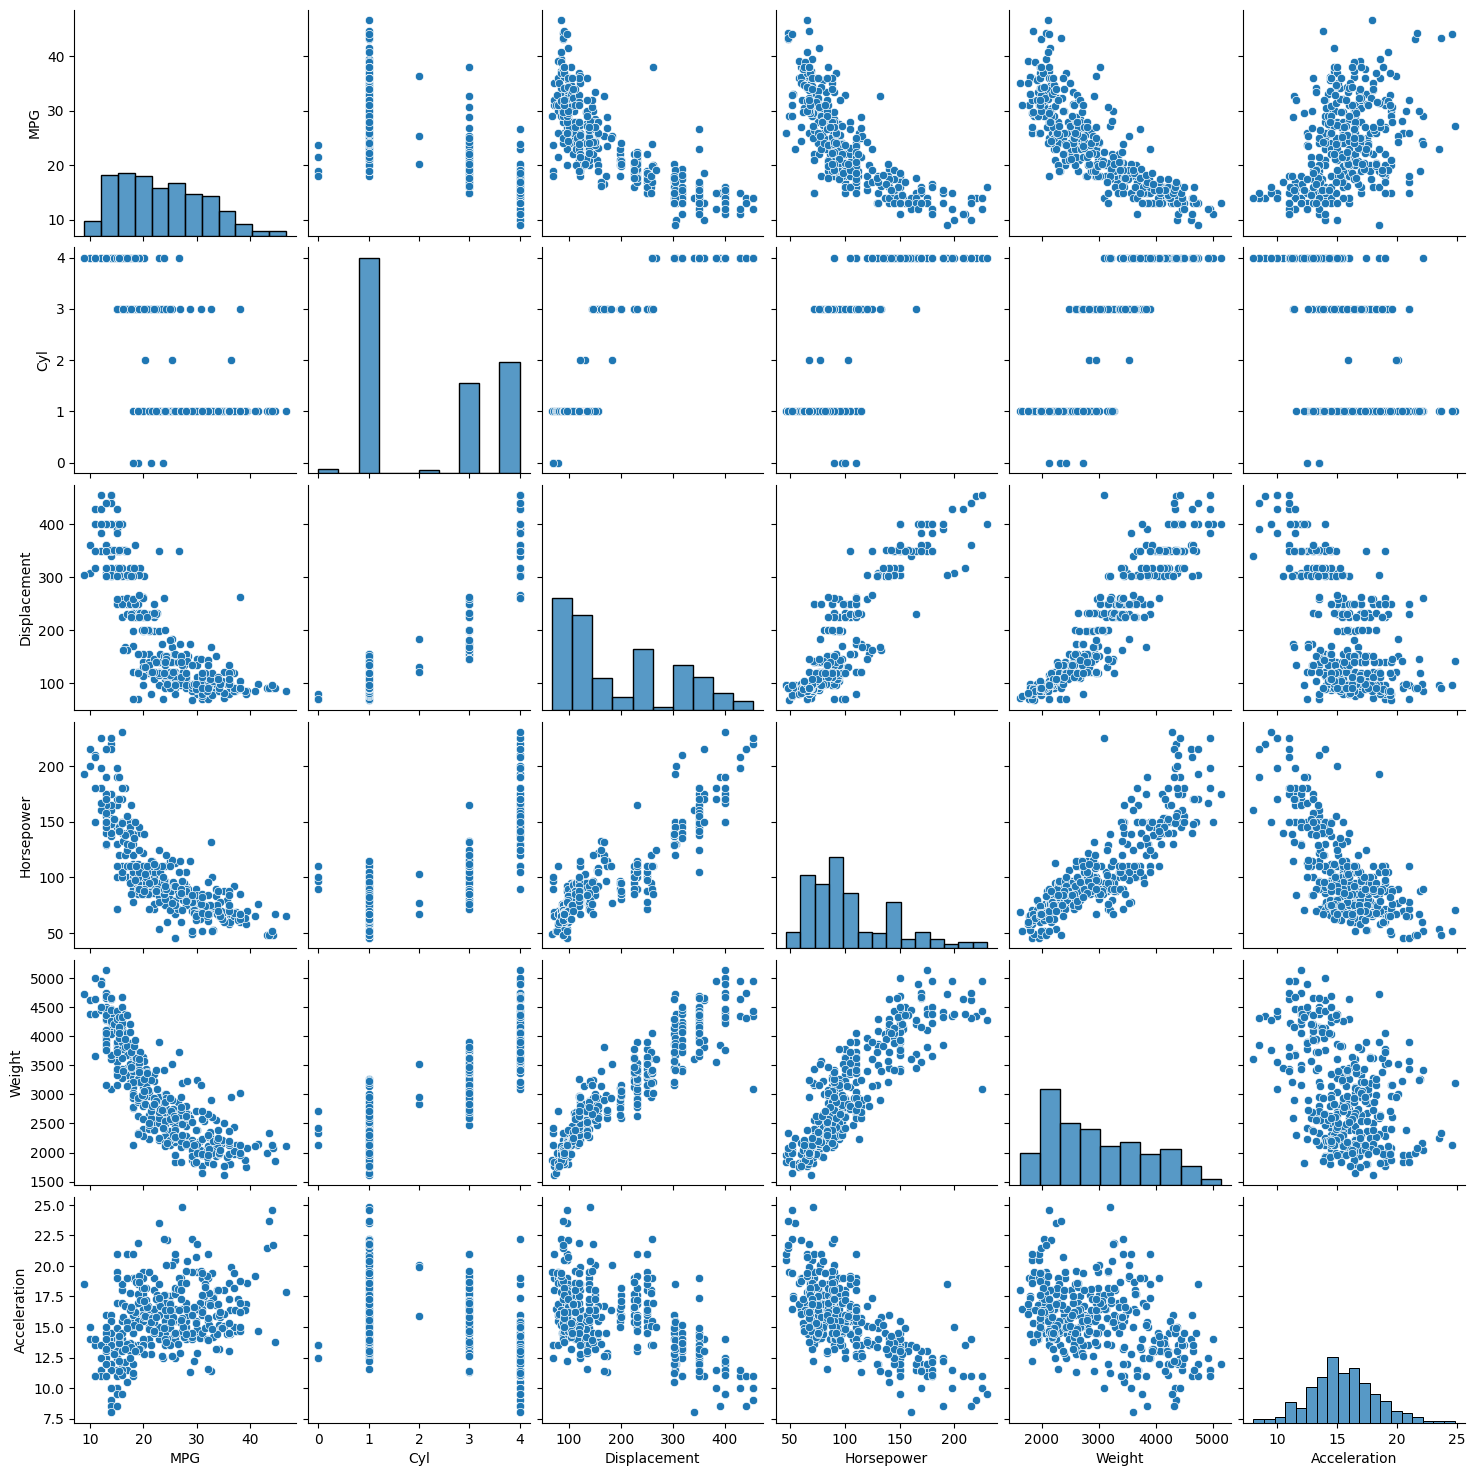

In [23]:
sns.pairplot(df)
plt.show()